In [1]:
# 1. Standard Library Imports
import importlib
import random
import sys
import time
from pathlib import Path

# 2. Third-Party Library Imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from cblearn import datasets
from scipy.cluster.hierarchy import fcluster
from scipy.optimize import linear_sum_assignment
from scipy.stats import kendalltau, spearmanr
from sklearn.manifold import TSNE
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    normalized_mutual_info_score,
    silhouette_score,
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
from tqdm.auto import tqdm

# 3. Path Configuration & Local Imports
ROOT = Path.cwd().resolve().parent
SRC_DIR = ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import model as src_model
import utils as src_utils



src_model = importlib.reload(src_model)
src_utils = importlib.reload(src_utils)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = ROOT / "data"
TRIPLET_DIR = DATA_DIR / "triplets"
QUADRUPLET_DIR = DATA_DIR / "quadruplets"
TRIPLET_DIR.mkdir(parents=True, exist_ok=True)
QUADRUPLET_DIR.mkdir(parents=True, exist_ok=True)
NATURE_VOGUE_ZIP = DATA_DIR / "nature_and_vogue_triplets.zip"

# Reuse helper functions from src
build_cosine_triplets_local = src_utils.build_cosine_triplets
average_linkage_from_similarity_local = src_utils.average_linkage_from_similarity
triplet_revenue_local = src_utils.triplet_revenue
compute_aari_local = src_utils.compute_aari
get_cblearn_array = src_utils.get_cblearn_array
load_car_triplets = src_utils.load_car_triplets
load_imagenet_triplets = src_utils.load_imagenet_triplets
load_offline_triplets = lambda dataset_name: src_utils.load_offline_triplets(dataset_name, NATURE_VOGUE_ZIP)
triplets_to_quadruplets = src_utils.triplets_to_quadruplets
compute_adds4_similarity = src_utils.compute_adds4_similarity
run_adds4_al = src_utils.run_adds4_al
run_4k_al = src_utils.run_4k_al
quadruplet_revenue = src_utils.quadruplet_revenue
load_palmer_penguins_2d = src_utils.load_palmer_penguins_2d
build_random_quadruplets_from_triplets = src_utils.build_random_quadruplets_from_triplets

# Model-level runners come directly from src/model.py
run_adds3_al = src_model.adds3_al
run_tste_al = src_model.tste_al
run_mulk3_al = src_model.mulk3_al

print("Setup done. Data folder:", TRIPLET_DIR)

Setup done. Data folder: D:\HCMUS\HK7\DM\lab3\DM-LAB3\data\triplets


In [2]:
# Cell 2 - Load real-valued datasets and build cosine triplets (with paper config)

# ================= PATH & CONFIG =================
ZOO_PATH = DATA_DIR / "zoo" / "zoo.csv"
GLASS_PATH = DATA_DIR / "glass" / "glass.csv"
MNIST_TRAIN_PATH = DATA_DIR / "mnist" / "mnist_train.csv"
MNIST_TEST_PATH = DATA_DIR / "mnist" / "mnist_test.csv"

k_values_table1 = [1.0]
MAX_TRIPLETS = 4_000_000  # Paper cap (mainly for MNIST)
N_REAL_TRIALS = 1     

# ================= 1. REAL DATA (ZOO, GLASS, MNIST) =================
print("========== BƯỚC 1: XỬ LÝ REAL DATA ==========")

dataset_loaders = {
    "zoo": lambda: src_utils.load_zoo_features(ZOO_PATH),
    "glass": lambda: src_utils.load_glass_features(GLASS_PATH),
    "mnist": lambda: src_utils.load_mnist_features(
        MNIST_TRAIN_PATH,
        MNIST_TEST_PATH,
        n_per_class=200,
        random_state=RANDOM_SEED,
    ),
}

real_data = {}
triplets_real = {}

for name, loader in dataset_loaders.items():
    print(f"\nProcessing {name.upper()}...")
    t0 = time.time()

    X, y = loader()
    X, y = src_utils.check_dataset(X, y, name)

    if name == "mnist":
        print(" -> Running t-SNE (2D embedding)...")
        X = TSNE(n_components=2, random_state=RANDOM_SEED, perplexity=30, init="pca").fit_transform(X)

    X = normalize(X)
    real_data[name] = {"X": X, "y": y}
    triplets_real[name] = {}
    n = X.shape[0]

    for kf in k_values_table1:
        if name == "zoo" and kf == 1.0:
            num_triplets = 100_000  # Hard-coded to match paper setting
        else:
            num_triplets = min(int(kf * n * n), MAX_TRIPLETS)

        triplets_real[name][kf] = []

        for rep in range(N_REAL_TRIALS):
            T = np.asarray(
                src_utils.build_cosine_triplets(
                    X,
                    k_factor=None,
                    num_triplets=num_triplets,
                    noise_rate=0.05,
                    random_state=RANDOM_SEED + rep,
                ),
                dtype=np.int64,
            )
            triplets_real[name][kf].append(T)

            # Save one canonical copy (rep=0) to preserve old downstream file layout
            if rep == 0:
                np.savez_compressed(
                    TRIPLET_DIR / f"{name}_k{str(kf).replace('.', '_')}.npz",
                    triplets=T,
                    labels=y,
                )

        print(
            f"  -> k={kf:<4} | {num_triplets:,} triplets/trial | "
        )

    print(f"Xong {name.upper()} trong {time.time() - t0:.2f}s")

# ================= 2. COMPARISON DATA =================
print("\n========== BƯỚC 2: XỬ LÝ COMPARISON DATA ==========")
comparison_loaders = {
    "car": load_car_triplets,
    "food": lambda: get_cblearn_array(datasets.fetch_food_similarity),
    "imagenet": load_imagenet_triplets,
    "vogue": lambda: load_offline_triplets("vogue"),
    "nature": lambda: load_offline_triplets("nature"),
}

cblearn_data = {}

for name, loader in comparison_loaders.items():
    try:
        print(f"Processing {name.upper():<10}...", end=" ")
        T = loader()
        T = np.asarray(T, dtype=np.int64)
        obj_ids = np.unique(T)

        cblearn_data[name] = {
            "triplets": T,
            "object_ids": obj_ids,
        }

        print(f"OK -> {len(T):>9,} triplets | {len(obj_ids):>5} objects")

        np.savez_compressed(
            TRIPLET_DIR / f"{name}.npz",
            triplets=T,
            object_ids=obj_ids,
        )

    except Exception as e:
        print(f"LỖI -> {e}")

# ================= 3. SUMMARY TABLE =================
summary_real = []
for name in real_data:
    n = real_data[name]["X"].shape[0]
    n_classes = int(len(np.unique(real_data[name]["y"])))
    for kf, trial_triplets in triplets_real[name].items():
        summary_real.append({
            "dataset": name,
            "n_objects": n,
            "n_classes": n_classes,
            "k_factor": kf,
            "n_triplets": len(trial_triplets[0]),
            "n_trials": len(trial_triplets),
        })

summary_cblearn = []
for name, data in cblearn_data.items():
    T = data["triplets"]
    summary_cblearn.append({
        "dataset": name,
        "n_objects": int(T.max()) + 1,
        "n_classes": None,
        "k_factor": None,
        "n_triplets": len(T),
        "n_trials": 1,
    })

summary_all = pd.concat([pd.DataFrame(summary_real), pd.DataFrame(summary_cblearn)], ignore_index=True)

print("\n========== BẢNG TỔNG KẾT ==========")
display(summary_all.sort_values(["dataset"]).reset_index(drop=True))

========== BƯỚC 1: XỬ LÝ REAL DATA ==========

Processing ZOO...
  -> k=1.0  | 100,000 triplets/trial | trials=1
Xong ZOO trong 1.73s

Processing GLASS...
  -> k=1.0  | 45,796 triplets/trial | trials=1
Xong GLASS trong 0.86s

Processing MNIST...
 -> Running t-SNE (2D embedding)...
  -> k=1.0  | 4,000,000 triplets/trial | trials=1
Xong MNIST trong 79.66s

========== BƯỚC 2: XỬ LÝ COMPARISON DATA ==========
Processing CAR       ... OK ->    14,194 triplets |    60 objects
Processing FOOD      ... OK ->   190,376 triplets |   100 objects
Processing IMAGENET  ... OK ->   278,003 triplets |  1000 objects
Processing VOGUE     ... OK ->     2,214 triplets |    60 objects
Processing NATURE    ... OK ->     6,710 triplets |   120 objects

========== BẢNG TỔNG KẾT ==========


,dataset,n_objects,n_classes,k_factor,n_triplets,n_trials
0,car,60,None,None,14194,1
1,food,100,None,None,190376,1
2,glass,214,6,1.0,45796,1
3,imagenet,1000,None,None,278003,1
4,mnist,2000,10,1.0,4000000,1
5,nature,120,None,None,6710,1
6,vogue,60,None,None,2214,1
7,zoo,100,7,1.0,100000,1


In [3]:
# Cell 3 - Load local triplets, generate quadruplets, prepare for evaluation

# Load all triplets from disk and generate corresponding quadruplets
comparison_data = []        
for triplet_path in sorted(TRIPLET_DIR.glob("*.npz")):
    loaded = np.load(triplet_path)
    triplets = np.asarray(loaded["triplets"], dtype=np.int64)
    object_ids = np.asarray(loaded["object_ids"]) if "object_ids" in loaded.files else np.arange(triplets.max() + 1)
    
    # Parse dataset name and k_factor from filename
    stem = triplet_path.stem
    if "_k" in stem:
        dataset, k_suffix = stem.split("_k", 1)
        try:
            k_factor = float(k_suffix.replace("_", "."))
        except ValueError:
            k_factor = np.nan
    else:
        dataset, k_factor = stem, np.nan
    
    # Generate quadruplets from triplets
    quadruplets = triplets_to_quadruplets(triplets)
    
    # Save quadruplets to disk
    quad_path = QUADRUPLET_DIR / triplet_path.name
    np.savez_compressed(quad_path, quadruplets=quadruplets, object_ids=object_ids)
    
    n_objects = int(triplets.max()) + 1 if triplets.size else 0
    
    comparison_data.append({
        "dataset": dataset,
        "k_factor": k_factor,
        "n_objects": n_objects,
        "n_triplets": len(triplets),
        "n_quadruplets": len(quadruplets),
        "triplets": triplets,
        "quadruplets": quadruplets,
        "object_ids": object_ids,
    })

# Summary table
print("\n=== Data Summary (Triplets + Quadruplets) ===")
summary_table = pd.DataFrame([
    {
        "dataset": item["dataset"],
        "k_factor": item["k_factor"],
        "n_objects": item["n_objects"],
        "n_triplets": item["n_triplets"],
        "n_quadruplets": item["n_quadruplets"],
    }
    for item in comparison_data
])
display(summary_table.sort_values(["dataset", "k_factor"]).reset_index(drop=True))


=== Data Summary (Triplets + Quadruplets) ===


,dataset,k_factor,n_objects,n_triplets,n_quadruplets
0,car,NaN,60,14194,14194
1,food,NaN,100,190376,190376
2,glass,1.0,214,45796,45796
3,imagenet,NaN,1000,278003,278003
4,mnist,1.0,2000,4000000,4000000
5,nature,NaN,120,6710,6710
6,vogue,NaN,60,2214,2214
7,zoo,1.0,100,100000,100000


Đang chạy mô phỏng Planted Model cho Figure 1...


SNR loop:   0%|          | 0/10 [00:00<?, ?it/s]

d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifo

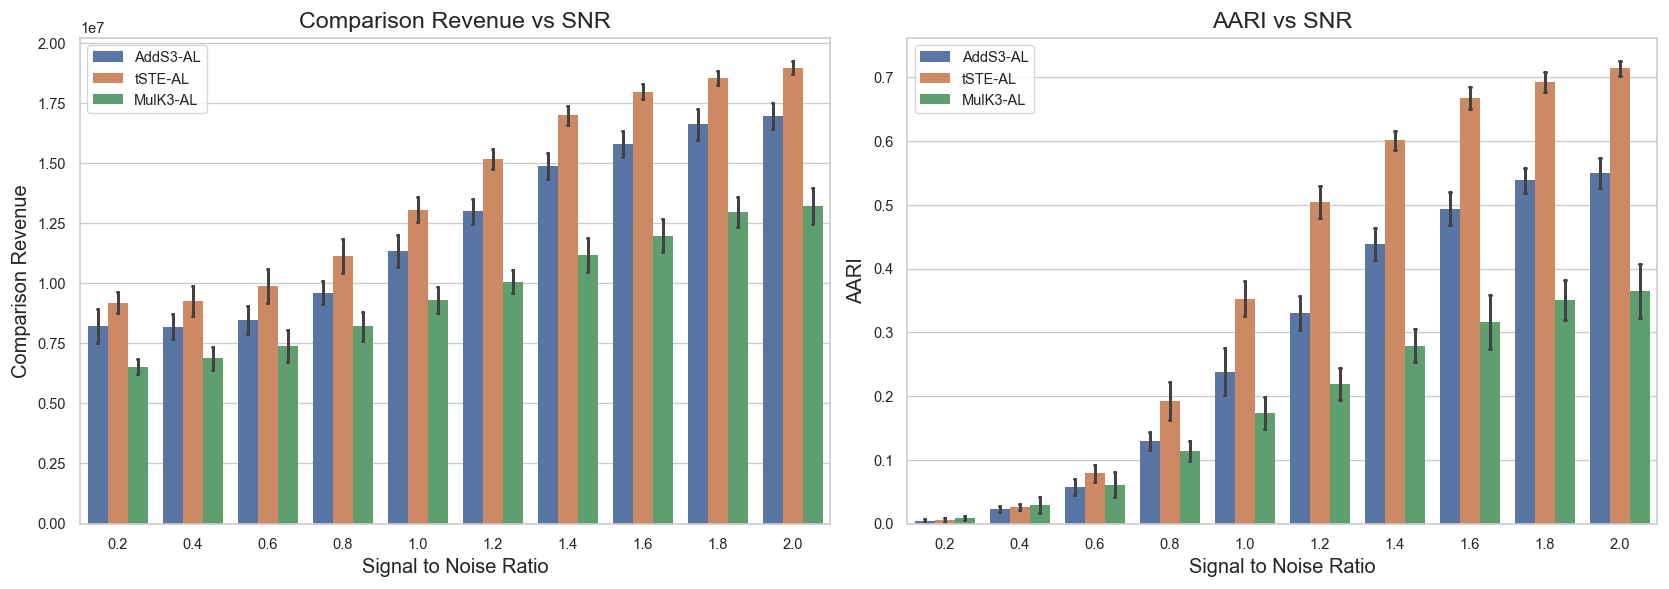

Đang chạy mô phỏng Table 1 (SNR = 1.5, n = 240)...


Triplets loop:   0%|          | 0/10 [00:00<?, ?it/s]

d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifo


===== TABLE 1 TÁI TẠO =====


method                  AddS3-AL              tSTE-AL             MulK3-AL  \
                         Revenue   AARI       Revenue   AARI       Revenue   
Number of triplets                                                           
16n^2               5.574 × 10^7  0.839  5.603 × 10^7  0.878  5.592 × 10^7   
8n^2                2.795 × 10^7  0.844  2.803 × 10^7  0.879  2.785 × 10^7   
4n^2                1.387 × 10^7  0.836  1.406 × 10^7  0.869  1.379 × 10^7   
2n^2                6.892 × 10^6  0.818  6.977 × 10^6  0.826  6.463 × 10^6   
n^2                 3.364 × 10^6  0.787  3.481 × 10^6  0.784  2.991 × 10^6   
n^2/2               1.640 × 10^6  0.735  1.719 × 10^6  0.708  1.291 × 10^6   
n^2/4               7.544 × 10^5  0.588  8.523 × 10^5  0.658  5.344 × 10^5   
n^2/8               3.511 × 10^5  0.455  3.822 × 10^5  0.505  2.347 × 10^5   
n^2/16              1.711 × 10^5  0.266  1.711 × 10^5  0.292  1.339 × 10^5   
n^2/32              9.578 × 10^4  0.122  8.168 × 10^4  0.085  7.605 × 10^4   

method                     
                     AARI  
Number of triplets         
16n^2               0.853  
8n^2                0.848  
4n^2                0.830  
2n^2                0.757  
n^2                 0.683  
n^2/2               0.501  
n^2/4               0.333  
n^2/8               0.222  
n^2/16              0.177  
n^2/32              0.068

In [4]:
# Cell 4 - Planted model experiments + Table 1 experiments (gộp Cell 4 & 5)

def make_planted_gaussian(n_per_cluster=40, n_clusters=6, snr=1.0, random_state=RANDOM_SEED):
    rng = np.random.default_rng(random_state)
    dim = 10
    
    # Tạo các tâm cụm trực giao (orthogonal) thay vì nằm chung một mặt phẳng
    centers = np.zeros((n_clusters, dim))
    for i in range(n_clusters):
        # Hệ số 2.5 giúp nới rộng khoảng cách, ép đồ thị vọt lên thành S-curve ở đúng mốc SNR=1.0
        centers[i, i] = snr * 2.5
        
    X = []
    y = []
    for c in range(n_clusters):
        # Sinh nhiễu Gaussian xung quanh tâm
        pts = rng.normal(loc=centers[c], scale=1.0, size=(n_per_cluster, dim))
        X.append(pts)
        y.extend([c] * n_per_cluster)
        
    return np.vstack(X), np.asarray(y)

# Figure 1 quét SNR từ 0.2 đến 2.0 (bước nhảy 0.2)
snr_values = np.round(np.arange(0.2, 2.1, 0.2), 1)

# Figure 1 dùng n^2 comparisons (tương đương k_factor = 1.0)
kf = 1.0

n_repeats = 10
planted_rows = []

print("Đang chạy mô phỏng Planted Model cho Figure 1...")
for snr in tqdm(snr_values, desc="SNR loop"):
    for rep in range(n_repeats):
        X, y = make_planted_gaussian(n_per_cluster=80, snr=snr, random_state=RANDOM_SEED + rep)
        
        # 2. Tạo triplets
        T = build_cosine_triplets_local(X, k_factor=kf, noise_rate=0.05, random_state=RANDOM_SEED + rep)

        # 3. Chạy 3 thuật toán
        methods = {
            "AddS3-AL": run_adds3_al,
            "tSTE-AL": run_tste_al,
            "MulK3-AL": run_mulk3_al,
        }
        
        for method, runner in methods.items():
            Z, _ = runner(len(X), T)
            rev = triplet_revenue_local(Z, T)
            aari = compute_aari_local(Z, y, max_clusters=8)
            
            planted_rows.append({
                "snr": snr,
                "repeat": rep,
                "method": method,
                "revenue": rev,
                "aari": aari,
            })

df_planted = pd.DataFrame(planted_rows)

# ================= VẼ BIỂU ĐỒ BAR CHART (FIGURE 1) =================
sns.set_theme(style="whitegrid", context="paper")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ trái: Revenue vs SNR
sns.barplot(
    data=df_planted, x="snr", y="revenue", hue="method",
    ax=axes[0], errorbar="sd", capsize=0.05, edgecolor="none"
)
axes[0].set_title("Comparison Revenue vs SNR", fontsize=14)
axes[0].set_ylabel("Comparison Revenue", fontsize=12)
axes[0].set_xlabel("Signal to Noise Ratio", fontsize=12)
axes[0].legend(title="")

# Biểu đồ phải: AARI vs SNR
sns.barplot(
    data=df_planted, x="snr", y="aari", hue="method",
    ax=axes[1], errorbar="sd", capsize=0.05, edgecolor="none"
)
axes[1].set_title("AARI vs SNR", fontsize=14)
axes[1].set_ylabel("AARI", fontsize=12)
axes[1].set_xlabel("Signal to Noise Ratio", fontsize=12)
axes[1].legend(title="")

plt.tight_layout()
plt.show()

# ===== Table 1 experiment =====
fixed_snr = 1.5
n_objects = 240
n_per_cluster = n_objects // 3  # 80 objects mỗi cluster
n_repeats = 10  # Lấy trung bình 10 lần chạy (trials)

# Các mốc k_factor tương ứng với cột "Number of triplets"
# 16n^2 -> k=16.0, ..., n^2/32 -> k=0.03125
k_factors = [16.0, 8.0, 4.0, 2.0, 1.0, 0.5, 0.25, 0.125, 0.0625, 0.03125]
k_labels = ["16n^2", "8n^2", "4n^2", "2n^2", "n^2", "n^2/2", "n^2/4", "n^2/8", "n^2/16", "n^2/32"]
k_dict = dict(zip(k_factors, k_labels))

table1_rows = []

print(f"Đang chạy mô phỏng Table 1 (SNR = {fixed_snr}, n = {n_objects})...")
for kf in tqdm(k_factors, desc="Triplets loop"):
    for rep in range(n_repeats):
        X, y = make_planted_gaussian(
            n_per_cluster=n_per_cluster, n_clusters=3, snr=fixed_snr, random_state=RANDOM_SEED + rep
        )

        # 2. Tạo triplets theo k_factor giảm dần
        T = build_cosine_triplets_local(X, k_factor=kf, noise_rate=0.05, random_state=RANDOM_SEED + rep)

        # 3. Chạy các thuật toán
        methods = {
            "AddS3-AL": run_adds3_al,
            "tSTE-AL": run_tste_al,
            "MulK3-AL": run_mulk3_al,
        }
        
        for method, runner in methods.items():
            Z, _ = runner(len(X), T)
            rev = triplet_revenue_local(Z, T)
            aari = compute_aari_local(Z, y, max_clusters=8)
            
            table1_rows.append({
                "k_factor_val": kf,  # Giữ lại để sort
                "Number of triplets": k_dict[kf],
                "method": method,
                "Revenue": rev,
                "AARI": aari,
            })

# ================= XỬ LÝ VÀ FORMAT BẢNG =================
df_table1 = pd.DataFrame(table1_rows)

# Tính trung bình cộng của 10 lần chạy
df_mean = df_table1.groupby(["k_factor_val", "Number of triplets", "method"])[["Revenue", "AARI"]].mean().reset_index()

# Xoay bảng (Pivot) để ghép cột Method và Metric (Revenue/AARI) cạnh nhau
pivot_table1 = df_mean.pivot(index=["k_factor_val", "Number of triplets"], columns="method", values=["Revenue", "AARI"])

# Căn chỉnh lại thứ tự cột cho y hệt Table 1 trong báo cáo
pivot_table1 = pivot_table1.swaplevel(0, 1, axis=1)[
    [("AddS3-AL", "Revenue"), ("AddS3-AL", "AARI"),
     ("tSTE-AL", "Revenue"), ("tSTE-AL", "AARI"),
     ("MulK3-AL", "Revenue"), ("MulK3-AL", "AARI")]
]

pivot_table1 = pivot_table1.sort_index(level=0, ascending=False).reset_index(level=0, drop=True)

def format_revenue(x):
    return f"{x:.3e}".replace("e+0", " × 10^").replace("e+", " × 10^").replace("e-", " × 10^-")

def format_aari(x):
    return f"{x:.3f}"

# Áp dụng format
for method in ["AddS3-AL", "tSTE-AL", "MulK3-AL"]:
    pivot_table1[(method, "Revenue")] = pivot_table1[(method, "Revenue")].apply(format_revenue)
    pivot_table1[(method, "AARI")] = pivot_table1[(method, "AARI")].apply(format_aari)

print("\n===== TABLE 1 TÁI TẠO =====")
display(pivot_table1)

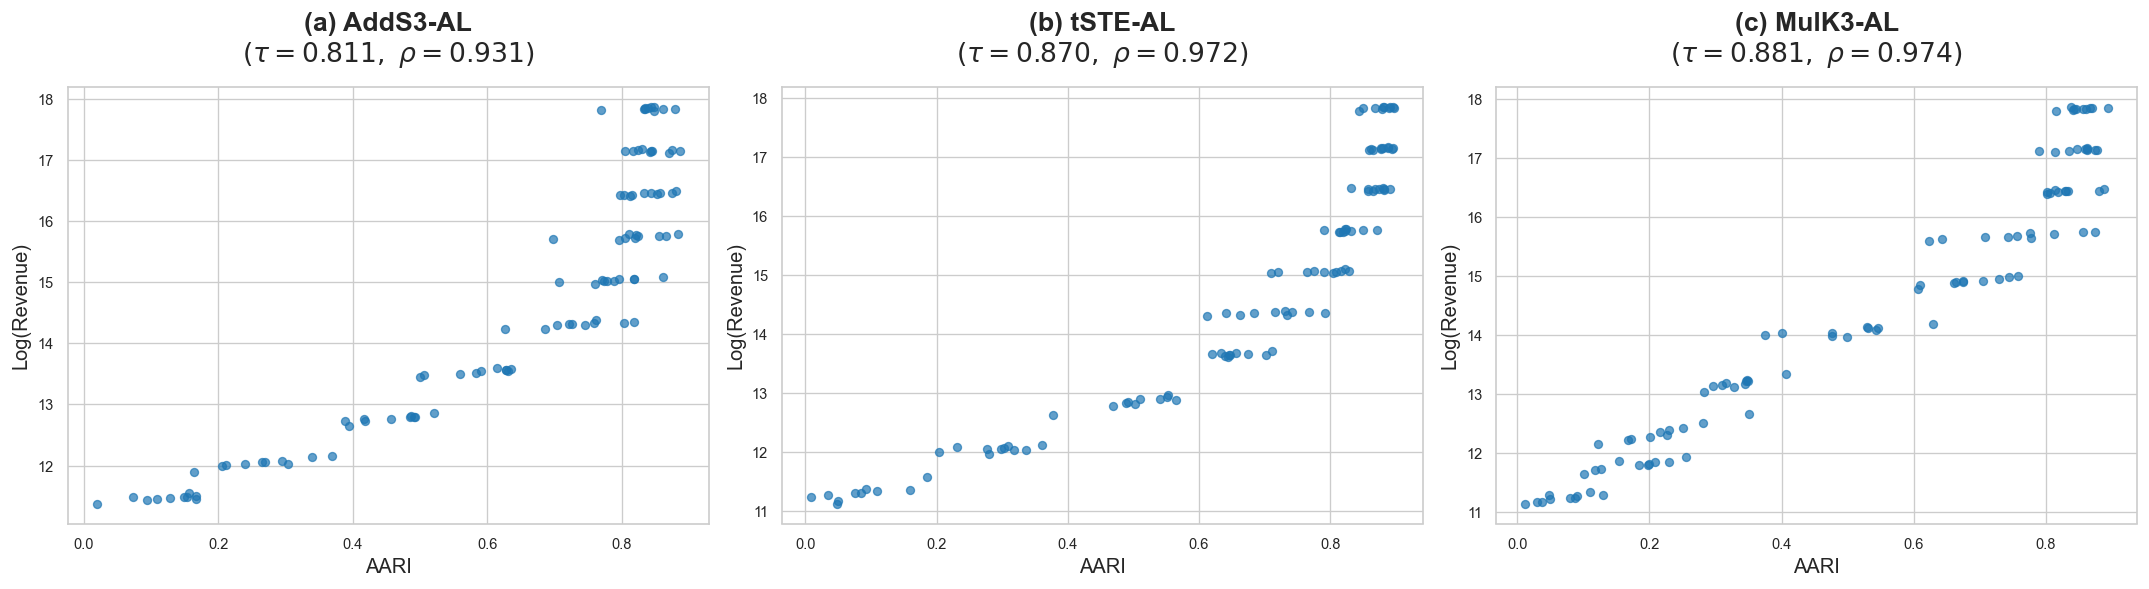

In [5]:
methods_to_plot = ["AddS3-AL", "tSTE-AL", "MulK3-AL"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, method in enumerate(methods_to_plot):
    # Lọc dữ liệu của từng phương pháp
    df_method = df_table1[df_table1["method"] == method].copy()
    
    # Lấy trục x (AARI) và trục y (Revenue gốc)
    x = df_method["AARI"].values
    y_raw = df_method["Revenue"].values
    
    # Tính Log(Revenue), loại bỏ các giá trị âm hoặc bằng 0 để tránh lỗi log
    y = np.log(np.maximum(y_raw, 1e-9))
    
    # Vẽ scatter plot
    axes[i].scatter(x, y, color="tab:blue", alpha=0.7)
    
    # Tính hệ số tương quan Kendall và Spearman
    tau, _ = kendalltau(x, y)
    rho, _ = spearmanr(x, y)
    
    # Trang trí biểu đồ
    axes[i].set_xlabel("AARI", fontsize=12)
    axes[i].set_ylabel("Log(Revenue)", fontsize=12)
    
    title = f"({chr(97+i)}) {method}\n" + r"$(\tau = {:.3f},\ \rho = {:.3f})$".format(tau, rho)
    axes[i].set_title(title, fontsize=16, fontweight="bold", pad=15)

plt.tight_layout()
plt.show()

In [6]:
paper_rows = []
real_dataset_names = set(real_data.keys())

# ===== Part A: Real datasets (Zoo, Glass, MNIST) with 10 independent trials =====
for dataset_name in tqdm(sorted(real_dataset_names), desc="Real datasets"):
    X = real_data[dataset_name]["X"]

    methods_triplet = {
        "AddS3-AL": run_adds3_al,
        "tSTE-AL": run_tste_al,
        "MulK3-AL": run_mulk3_al,
    }

    S_cos = cosine_similarity(X)
    Z_cos = average_linkage_from_similarity_local(S_cos)

    for kf, trial_triplets in tqdm(triplets_real[dataset_name].items(), desc=f"k ({dataset_name})", leave=False):
        for rep, T in enumerate(tqdm(trial_triplets, desc="Trials", leave=False)):
            # Triplet methods
            for method, runner in methods_triplet.items():
                Z, _ = runner(len(X), T)
                paper_rows.append({
                    "dataset": dataset_name,
                    "k_factor": kf,
                    "rep": rep,
                    "family": "Triplet",
                    "method": method,
                    "revenue": triplet_revenue_local(Z, T),
                })

            # Triplet cosine baseline
            paper_rows.append({
                "dataset": dataset_name, "k_factor": kf, "rep": rep,
                "family": "Triplet", "method": "Cosine-AL",
                "revenue": triplet_revenue_local(Z_cos, T),
            })

            # Quadruplets derived per-trial from current triplets
            Q = triplets_to_quadruplets(T)

            Z4, _ = run_adds4_al(len(X), Q)
            paper_rows.append({
                "dataset": dataset_name, "k_factor": kf, "rep": rep,
                "family": "Quadruplet", "method": "AddS4-AL",
                "revenue": quadruplet_revenue(Z4, Q),
            })

            Z4k, _ = run_4k_al(len(X), Q)
            paper_rows.append({
                "dataset": dataset_name, "k_factor": kf, "rep": rep,
                "family": "Quadruplet", "method": "4K-AL",
                "revenue": quadruplet_revenue(Z4k, Q),
            })

            paper_rows.append({
                "dataset": dataset_name, "k_factor": kf, "rep": rep,
                "family": "Quadruplet", "method": "Cosine-AL",
                "revenue": quadruplet_revenue(Z_cos, Q),
            })

# ===== Part B: Comparison datasets (single trial from provided triplets) =====
for item in tqdm(comparison_data, desc="Comparison datasets"):
    dataset_name = item["dataset"]
    if dataset_name in real_dataset_names:
        continue

    T = item["triplets"]
    Q = item["quadruplets"]
    n = item["n_objects"]

    methods_triplet = {
        "AddS3-AL": run_adds3_al,
        "tSTE-AL": run_tste_al,
        "MulK3-AL": run_mulk3_al,
    }

    for method, runner in methods_triplet.items():
        Z, _ = runner(n, T)
        paper_rows.append({
            "dataset": dataset_name, "k_factor": np.nan, "rep": 0,
            "family": "Triplet", "method": method,
            "revenue": triplet_revenue_local(Z, T),
        })

    Z4, _ = run_adds4_al(n, Q)
    paper_rows.append({
        "dataset": dataset_name, "k_factor": np.nan, "rep": 0,
        "family": "Quadruplet", "method": "AddS4-AL",
        "revenue": quadruplet_revenue(Z4, Q),
    })

    Z4k, _ = run_4k_al(n, Q)
    paper_rows.append({
        "dataset": dataset_name, "k_factor": np.nan, "rep": 0,
        "family": "Quadruplet", "method": "4K-AL",
        "revenue": quadruplet_revenue(Z4k, Q),
    })

df_paper_eval = pd.DataFrame(paper_rows)

mask_full_data = df_paper_eval["k_factor"].isna() | (df_paper_eval["k_factor"] == 1.0)

# Average over rep to get one row per dataset, family, method
agg = (
    df_paper_eval[mask_full_data]
    .groupby(["dataset", "family", "method"], as_index=False)["revenue"]
    .mean()
    .sort_values(["dataset", "family", "method"])
)

triplet_table = (
    agg[agg["family"] == "Triplet"]
    .pivot(index="dataset", columns="method", values="revenue")
    .reindex(columns=["AddS3-AL", "tSTE-AL", "MulK3-AL", "Cosine-AL"])
)

quadruplet_table = (
    agg[agg["family"] == "Quadruplet"]
    .pivot(index="dataset", columns="method", values="revenue")
    .reindex(columns=["AddS4-AL", "4K-AL", "Cosine-AL"])
)

dataset_order = ["zoo", "glass", "mnist", "car", "food", "vogue", "nature", "imagenet"]
dataset_label = {"zoo": "Zoo", "glass": "Glass", "mnist": "MNIST", "car": "Car", "food": "Food", "vogue": "Vogue", "nature": "Nature", "imagenet": "Imagenet"}

table_paper_raw = pd.concat([triplet_table, quadruplet_table], axis=1)
table_paper_raw = table_paper_raw.reindex(dataset_order)
table_paper_raw.index = [dataset_label.get(x, x) for x in table_paper_raw.index]
table_paper_raw.index.name = "Dataset"

# Raw output only
print("\n===== BẢNG REVENUE TỔNG KẾT =====")
display(table_paper_raw.fillna("-"))


# ===== ACC (Hungarian matching) =====
def clustering_accuracy(y_true, y_pred):
    y_true = y_true.astype(int)
    y_pred = y_pred.astype(int)
    D = max(y_pred.max(), y_true.max()) + 1
    w = np.zeros((D, D), dtype=np.int64)
    for i in range(len(y_true)):
        w[y_pred[i], y_true[i]] += 1
    row_ind, col_ind = linear_sum_assignment(w.max() - w)
    return w[row_ind, col_ind].sum() / len(y_true)

def get_labels(Z, n_clusters):
    return fcluster(Z, t=n_clusters, criterion="maxclust") - 1


# ===== MAIN =====
rows = []

for dataset_name, obj in tqdm(real_data.items(), desc="Datasets"):
    X = obj["X"]
    y_true = obj["y"]
    n_clusters = len(np.unique(y_true))

    for kf, trial_triplets in tqdm(triplets_real[dataset_name].items(), desc=f"{dataset_name} k_factor", leave=False):
        for rep, T in enumerate(trial_triplets):
            methods = {
                "AddS3-AL": run_adds3_al,
                "tSTE-AL": run_tste_al,
                "MulK3-AL": run_mulk3_al,
            }

            for method, runner in methods.items():
                Z, _ = runner(len(X), T)
                y_pred = get_labels(Z, n_clusters)

                # ===== supervised =====
                acc = clustering_accuracy(y_true, y_pred)
                nmi = normalized_mutual_info_score(y_true, y_pred)
                ari = adjusted_rand_score(y_true, y_pred)

                # ===== unsupervised =====
                try:
                    sil = silhouette_score(X, y_pred)
                    db = davies_bouldin_score(X, y_pred)
                    ch = calinski_harabasz_score(X, y_pred)
                except:
                    sil, db, ch = np.nan, np.nan, np.nan

                rows.append({
                    "dataset": dataset_name,
                    "k_factor": kf,
                    "rep": rep, # Ghi nhận trial thứ mấy
                    "method": method,
                    "ACC": acc, "NMI": nmi, "ARI": ari,
                    "Silhouette": sil, "DB": db, "CH": ch,
                })

df_metrics = pd.DataFrame(rows)

print("\n===== FULL METRICS =====")
display(df_metrics)

# ===== SUMMARY =====
df_metrics_final = df_metrics[df_metrics["k_factor"] == 1.0]

summary = (
    df_metrics_final
    .groupby(["dataset", "method"], as_index=False)
    .mean(numeric_only=True)
    .drop(columns=["k_factor", "rep"])
    .sort_values(["dataset", "ARI"], ascending=[True, False])
)

print("\n===== SUMMARY =====")
display(summary)

Real datasets:   0%|          | 0/3 [00:00<?, ?it/s]

k (glass):   0%|          | 0/1 [00:00<?, ?it/s]

Trials:   0%|          | 0/1 [00:00<?, ?it/s]

d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


k (mnist):   0%|          | 0/1 [00:00<?, ?it/s]

...

d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(



===== FULL METRICS =====


,dataset,k_factor,rep,method,ACC,NMI,ARI,Silhouette,DB,CH
0,zoo,1.0,0,AddS3-AL,0.780000,0.763648,0.708436,0.400208,0.890577,45.923543
1,zoo,1.0,0,tSTE-AL,0.630000,0.700596,0.528350,0.328125,0.972818,42.963703
2,zoo,1.0,0,MulK3-AL,0.640000,0.725930,0.535080,0.360367,1.143097,46.098439
3,glass,1.0,0,AddS3-AL,0.523364,0.340718,0.254260,0.273679,1.047527,97.872960
4,glass,1.0,0,tSTE-AL,0.448598,0.293913,0.179053,-0.038058,1.958779,37.157917
5,glass,1.0,0,MulK3-AL,0.518692,0.315589,0.241250,0.191394,1.611629,55.698661
6,mnist,1.0,0,AddS3-AL,0.305000,0.239391,0.148791,0.290024,2.788924,1602.106832
7,mnist,1.0,0,tSTE-AL,0.290000,0.224426,0.134491,0.188801,5.304808,1525.379507
8,mnist,1.0,0,MulK3-AL,0.268500,0.223905,0.130143,0.200035,36.831677,194.524376



===== SUMMARY (Avg 10 trials - 100% data) =====


,dataset,method,ACC,NMI,ARI,Silhouette,DB,CH
0,glass,AddS3-AL,0.523364,0.340718,0.254260,0.273679,1.047527,97.872960
1,glass,MulK3-AL,0.518692,0.315589,0.241250,0.191394,1.611629,55.698661
2,glass,tSTE-AL,0.448598,0.293913,0.179053,-0.038058,1.958779,37.157917
3,mnist,AddS3-AL,0.305000,0.239391,0.148791,0.290024,2.788924,1602.106832
5,mnist,tSTE-AL,0.290000,0.224426,0.134491,0.188801,5.304808,1525.379507
4,mnist,MulK3-AL,0.268500,0.223905,0.130143,0.200035,36.831677,194.524376
6,zoo,AddS3-AL,0.780000,0.763648,0.708436,0.400208,0.890577,45.923543
7,zoo,MulK3-AL,0.640000,0.725930,0.535080,0.360367,1.143097,46.098439
8,zoo,tSTE-AL,0.630000,0.700596,0.528350,0.328125,0.972818,42.963703
